## Astro kod

### Parser

Filename: data/RDor/R_Dor_Band4_2023-10-03.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     272   (512, 512, 1, 1)   float32   
Filename: data/RDor/R_Dor_Band7_2023-10-04.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     272   (512, 512, 1, 1)   float32   
Filename: data/RDor/R_Dor_Band9_2023-11-04.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     272   (512, 512, 1, 1)   float32   
Filename: data/RDor/R_Dor_Band7_2023-10-06.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     272   (512, 512, 1, 1)   float32   
Filename: data/RDor/R_Dor_Band4_2023-10-09.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     272   (512, 512, 1, 1)   float32   
Filename: data/RDor/R_Dor_Band8_2023-11-03.fits
No.    Name      Ver    Type      Cards   

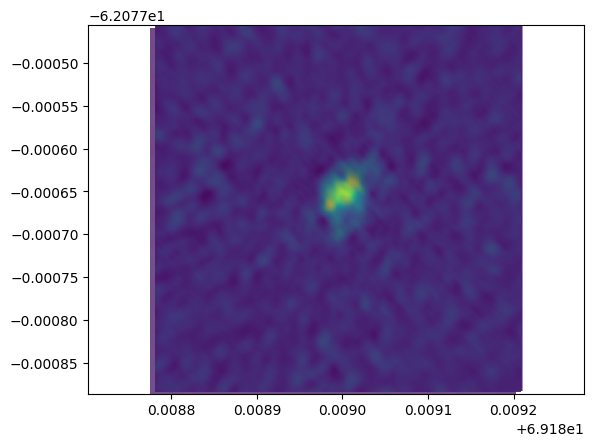

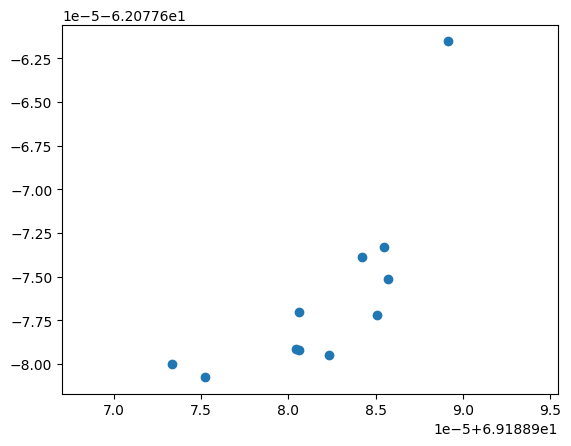

In [ ]:
# Parser
import numpy as np
import scipy as sci
import astropy as aspy
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import fits


from os import listdir
from os.path import isfile, join
import time

# Hämta lista av fits filer från mapp
#data_dir = "data/RDor/"
#data_dir = "data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/RLeo/"
data_dir = "data/aop_mount/home/wouterv/DATA/AGB_Continuum_files/WHya/"
data_files = [f for f in listdir(data_dir) if isfile(join(data_dir, f))]

# Initiera positionlista
Xs = np.empty(0)
Ys = np.empty(0)

# Gå igenom varje fits fil
for data_file in data_files[:]:
    # Öppna fitsfil
    # HDUList (Header Data Unit)
    hdul = fits.open(data_dir + data_file)
    hdul.info() # Printar lite info om fitsfilen

    # Header information
    header = hdul[0].header
    #print(repr(header))

    # Bilddatan
    image_data = np.squeeze(hdul[0].data)

    width, height = image_data.shape
    x_pixels = np.linspace(0, width, width)
    y_pixels = np.linspace(0, height, height)

    # Right ascension
    ra_ref = header['CRVAL1'] # RA referens i relation till Pixel referencen
    ra_delta = header['CDELT1'] # RA delta för varje pixel
    ra_pixel_ref = header['CRPIX1'] # Pixel positonen där RA referens gäller

    # Declination
    dec_ref = header['CRVAL2']
    dec_delta = header['CDELT2']
    dec_pixel_ref = header['CRPIX2']

    # Frekvensen (fungerar inte för alla objekt)

    #frequency = header['CRVAL3']
    #frequency_delta = header['CDELT3']

    # Tillfälligt, beräkna fram:
    # To deg, arcmin, arcsec

    #dec_ref -= dec_delta * 512/2
    #print(dec_ref)
    #dec_deg = int(dec_ref)
    #print(60 * (dec_ref - dec_deg))
    #dec_arcmin = int(60 * (dec_ref - dec_deg))
    #dec_arcsec = 60 * (60 * (dec_ref - dec_deg) - dec_arcmin)
    
    #print(dec_deg, "deg", np.abs(dec_arcmin), "arcmin", np.abs(dec_arcsec), "arcsec")

    # Konvertera från pixel koordinat till ekvatoriella koordinater
    xs = ra_ref + (x_pixels - ra_pixel_ref) * ra_delta
    ys = dec_ref + (y_pixels - dec_pixel_ref) * dec_delta
    
    # Testar hitta centrum med ljusaste punkt:
    # Hämta index för ljusaste intensitet
    xp, yp = np.unravel_index(np.argmax(image_data, axis=None), image_data.shape)
    # Lägg ekvatoriella koordinaten för ljusate punkt
    Xs = np.append(Xs, xs[xp])
    Ys = np.append(Ys, ys[yp])

    # Plotta färgkarta över ljusintensiteten för varje bild
    plt.pcolormesh(xs, ys, image_data, alpha=0.5)
    hdul.close()

plt.axis('equal')
plt.show()

# Plotta test för centrum av ljusaste punkt
plt.axis('equal')
plt.scatter(Xs, Ys)
plt.show()


### Centrum metoder

In [2]:
# Centrum metoder

### Parallax (+Bootstrap)

In [3]:
# Bootstrap

# Parallax

### Analys

In [4]:
# Analys